# Data Set Description

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn import metrics

from scipy.stats import skew
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,ConfusionMatrixDisplay, roc_curve, auc ,roc_auc_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/SAML-D.csv'

df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("First 5 rows of the dataset:\n", df.head())

First 5 rows of the dataset:
        Time        Date  Sender_account  Receiver_account    Amount  \
0  10:35:19  2022-10-07      8724731955        2769355426   1459.15   
1  10:35:20  2022-10-07      1491989064        8401255335   6019.64   
2  10:35:20  2022-10-07       287305149        4404767002  14328.44   
3  10:35:21  2022-10-07      5376652437        9600420220  11895.00   
4  10:35:21  2022-10-07      9614186178        3803336972    115.25   

  Payment_currency Received_currency Sender_bank_location  \
0        UK pounds         UK pounds                   UK   
1        UK pounds            Dirham                   UK   
2        UK pounds         UK pounds                   UK   
3        UK pounds         UK pounds                   UK   
4        UK pounds         UK pounds                   UK   

  Receiver_bank_location  Payment_type  Is_laundering       Laundering_type  
0                     UK  Cash Deposit              0  Normal_Cash_Deposits  
1                   

In [ ]:
# Shape of dataset
print("Shape of the dataset:\n", df.shape)

Shape of the dataset:
 (9504852, 12)


In [ ]:
# Check duplicate records:
duplicates = df.duplicated()
num_duplicates = duplicates.sum()
print(f"Numbers of duplicated rows: {num_duplicates}")

Numbers of duplicated rows: 0


In [ ]:
# Find range of date
df['Date'] = pd.to_datetime(df['Date'])

# If Date column is of the type object otherwise skip this ^
date_range = str(df['Date'].dt.date.min()) + ' to ' + str(df['Date'].dt.date.max())
print(date_range)

2022-10-07 to 2023-08-23


In [ ]:
# Find min and max of time
print(df['Time'].min())
print(df['Time'].max())


# Find min and max of money sent
print(df['Amount'].max())
print(df['Amount'].min())

00:00:00
23:59:59
12618498.4
3.73


In [ ]:
# Find number of Unique Values for each columns
print(df.nunique())

Time                        86400
Date                          321
Sender_account             292715
Receiver_account           652266
Amount                    2314277
Payment_currency               13
Received_currency              13
Sender_bank_location           18
Receiver_bank_location         18
Payment_type                    7
Is_laundering                   2
Laundering_type                28
dtype: int64


In [ ]:
# Find missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64


# High-level Statistics

In [ ]:
#Statistical summary

#1. Data Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Time                    object        
 1   Date                    datetime64[ns]
 2   Sender_account          int64         
 3   Receiver_account        int64         
 4   Amount                  float64       
 5   Payment_currency        object        
 6   Received_currency       object        
 7   Sender_bank_location    object        
 8   Receiver_bank_location  object        
 9   Payment_type            object        
 10  Is_laundering           int64         
 11  Laundering_type         object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(7)
memory usage: 870.2+ MB
None


In [ ]:
#2. Check class distribution
print()
df['Is_laundering'].value_counts(normalize=True)
  # Note here - <1% flagged transactions (imbalance), to address before model training

,proportion
Is_laundering,
0,0.998961
1,0.001039


In [ ]:
#3. Descriptive Statistics
print()
print(df.describe())


                                Date  Sender_account  Receiver_account  \
count                        9504852    9.504852e+06      9.504852e+06   
mean   2023-03-15 21:03:37.048723968    5.006619e+09      5.006006e+09   
min              2022-10-07 00:00:00    9.018000e+03      9.018000e+03   
25%              2022-12-27 00:00:00    2.513133e+09      2.513219e+09   
50%              2023-03-15 00:00:00    5.001017e+09      5.002572e+09   
75%              2023-06-03 00:00:00    7.505051e+09      7.502397e+09   
max              2023-08-23 00:00:00    9.999987e+09      9.999971e+09   
std                              NaN    2.885814e+09      2.884763e+09   

             Amount  Is_laundering  
count  9.504852e+06   9.504852e+06  
mean   8.762968e+03   1.038733e-03  
min    3.730000e+00   0.000000e+00  
25%    2.143688e+03   0.000000e+00  
50%    6.113720e+03   0.000000e+00  
75%    1.045846e+04   0.000000e+00  
max    1.261850e+07   1.000000e+00  
std    2.561495e+04   3.221263e-02  

In [ ]:
#4. Categorical Summary
for col in df.select_dtypes(include='object'):
    print(f"\nTop categories in {col}:\n{df[col].value_counts()}")


Top categories in Time:
Time
15:22:42    201
14:09:05    199
11:35:00    199
14:49:56    198
14:51:59    196
           ... 
04:04:46     14
03:38:32     14
03:03:05     13
02:29:43     13
03:39:29     12
Name: count, Length: 86400, dtype: int64

Top categories in Payment_currency:
Payment_currency
UK pounds          9099293
Euro                117164
Turkish lira         27996
Swiss franc          27492
Dirham               27263
Pakistani rupee      27196
Naira                27143
US dollar            26061
Yen                  25562
Moroccan dirham      25395
Mexican Peso         24852
Albanian lek         24778
Indian rupee         24657
Name: count, dtype: int64

Top categories in Received_currency:
Received_currency
UK pounds          8783655
Euro                231911
Pakistani rupee      45993
Yen                  45814
Moroccan dirham      45748
Albanian lek         45736
Mexican Peso         45255
Naira                45046
Indian rupee         43757
US dollar            43

In [ ]:
#5. Grouped Statistics
print(df.groupby('Is_laundering')['Amount'].describe())

                   count          mean            std    min      25%  \
Is_laundering                                                           
0              9494979.0   8729.875874   21750.032069   3.73  2142.93   
1                 9873.0  40587.666906  419181.131445  15.82  2723.79   

                   50%           75%          max  
Is_laundering                                      
0              6114.63  10458.950000    999962.19  
1              5322.79   9789.673317  12618498.40  


**Exploratory Data Analysis**

5 Key Questions to guide our EDA

    1. What are the most flagged payment types?
    2. What are the most common types of money laundering in the suspicious transactions?
    3. Do suspicious transactions involve larger amounts?
    4. Are suspicious transactions observed more frequently between certain receivers?
    5. How has the volume of flagged transactions changed over time?




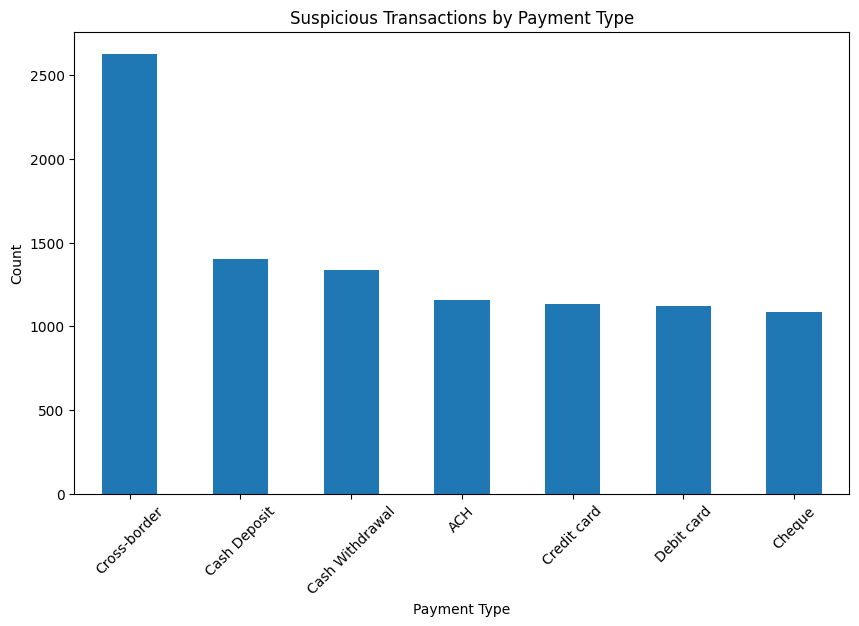

In [ ]:
#1. What are the most flagged payment types?

suspect_counts = df[df['Is_laundering'] == 1]['Payment_type'].value_counts()

suspect_counts.plot(kind='bar', figsize=(10,6))
plt.title('Suspicious Transactions by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

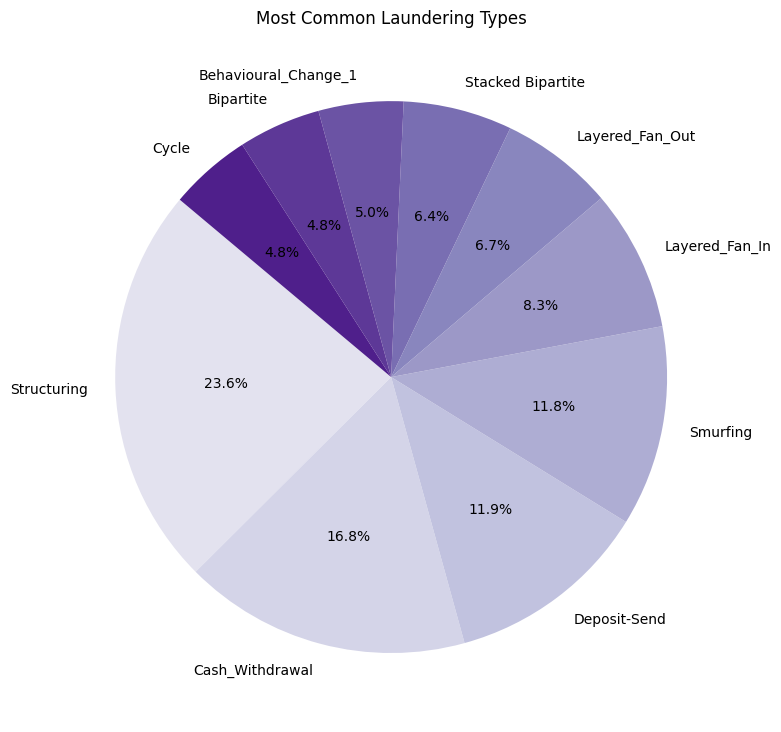

In [ ]:
#2. What are the most common types of money laundering in the suspicious transactions?

suspect_laundering = df[df['Is_laundering'] == 1]['Laundering_type']
top_laundering = suspect_laundering.value_counts().head(10)

plt.figure(figsize=(8,8))
top_laundering.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Purples(range(50, 250, 20)))
plt.title('Most Common Laundering Types')
plt.ylabel('')
plt.tight_layout()
plt.show()


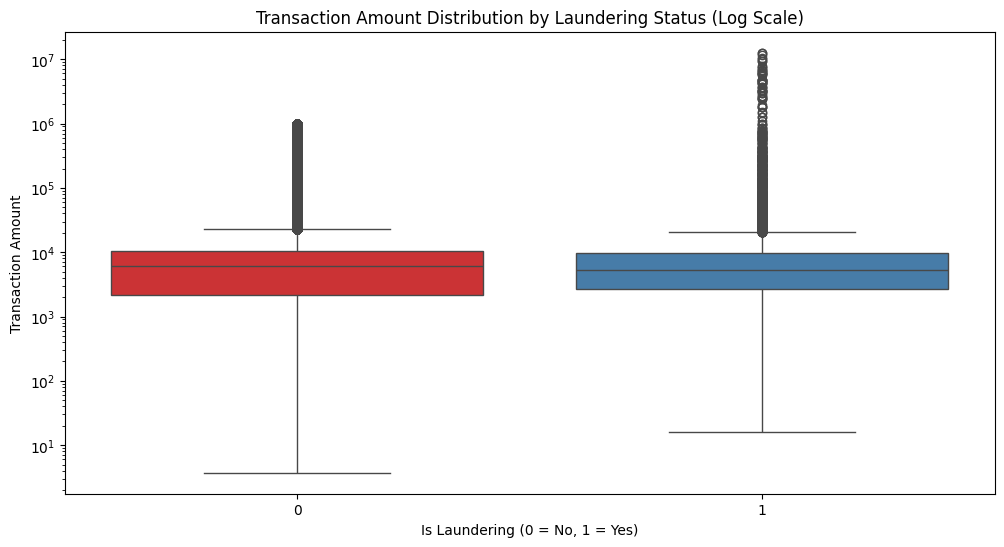

In [ ]:
#3. Do suspicious transactions tend to have larger amounts?

plt.figure(figsize=(12,6))
sns.boxplot(x='Is_laundering', y='Amount', data=df, hue='Is_laundering', palette='Set1')
plt.title('Transaction Amount Distribution by Laundering Status (Log Scale)')
plt.xlabel('Is Laundering (0 = No, 1 = Yes)')
plt.ylabel('Transaction Amount')
plt.yscale('log')
plt.legend().remove()
plt.show()

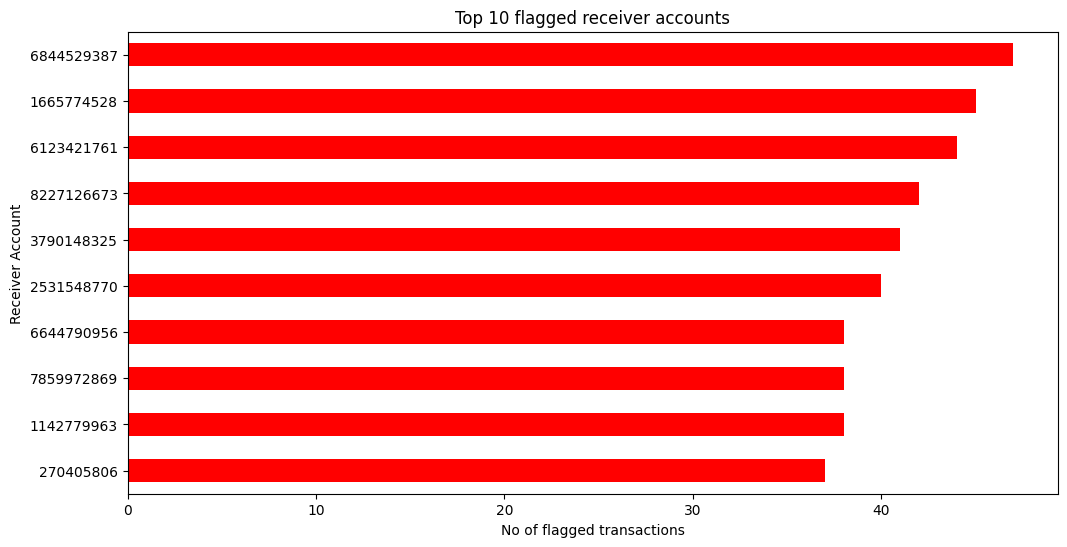

In [ ]:
#4. Are suspicious transactions observed more frequently between certain receivers?

top_receivers = df[df['Is_laundering'] == 1]['Receiver_account'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_receivers.plot(kind='barh', color='red')
plt.title('Top 10 flagged receiver accounts')
plt.xlabel('No of flagged transactions')
plt.ylabel('Receiver Account')
plt.gca().invert_yaxis()
plt.show()

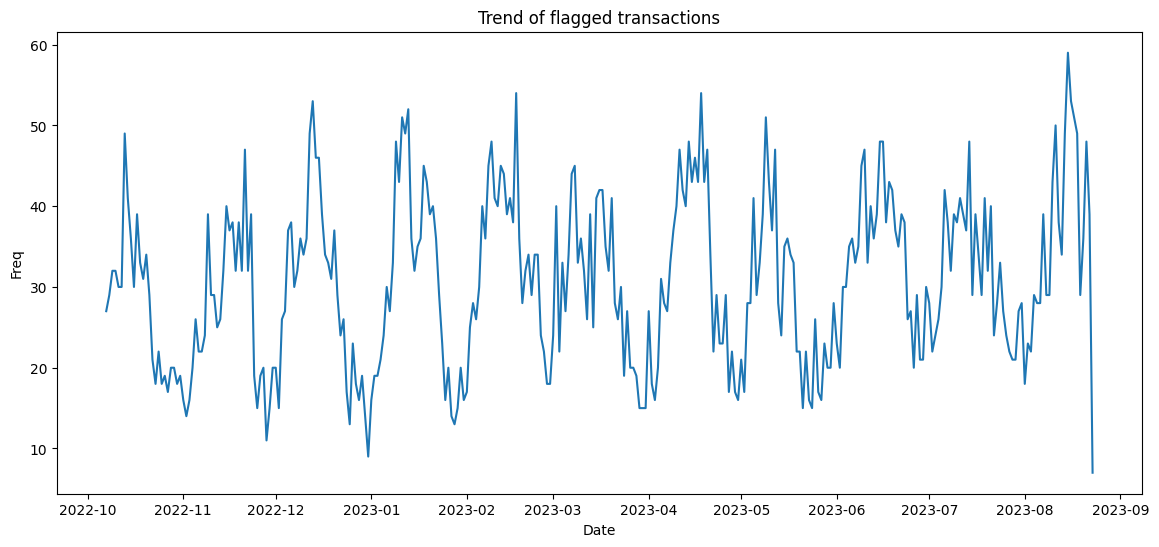

In [ ]:
#5. How has the volume of flagged transactions changed over time?

df['DateTime'] = pd.to_datetime(df['Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Time'])
daily_suspicious = df[df['Is_laundering'] == 1].groupby(df['DateTime'].dt.date).size()

plt.figure(figsize=(14,6))
daily_suspicious.plot()
plt.title('Trend of flagged transactions')
plt.xlabel('Date')
plt.ylabel('Freq')
plt.show()

# Data Preprocessing and Issues

In [ ]:
#Time taken to read the whole dataset
import time
start_time = time.time()

df = pd.read_csv(file_path)
end_time = time.time()
processing_time = end_time - start_time
print(f"Time taken to read the full dataset: {processing_time} seconds")

Time taken to read the full dataset: 35.613590478897095 seconds


In [ ]:
#Time taken to read only 200,000 rows
start_time = time.time()

#Random sampling of 200000 from the dataset
df = df.sample(n=200000, random_state=1)
end_time = time.time()
processing_time = end_time - start_time
print(f"Time taken to read 200000 rows: {processing_time} seconds")

Time taken to read 200000 rows: 1.021148920059204 seconds


In [ ]:
# Display the first 5 row of the data
print("First 5 rows of the dataset:\n", df.head())

First 5 rows of the dataset:
              Time        Date  Sender_account  Receiver_account    Amount  \
9232719  02:08:46  2023-08-14      4248061080        9527052910  13480.74   
7996180  19:48:23  2023-07-02      9130896737         908371799  10480.05   
8575435  12:04:24  2023-07-22      1466348255        8545558838  26232.35   
614744   17:08:02  2022-10-28      2181923623        6234034932    447.07   
4092093  22:44:17  2023-02-21      8596132461        3638213339   1005.62   

        Payment_currency Received_currency Sender_bank_location  \
9232719     Mexican Peso         UK pounds                   UK   
7996180        UK pounds         UK pounds                   UK   
8575435        UK pounds         UK pounds                   UK   
614744         UK pounds         UK pounds                   UK   
4092093        UK pounds         UK pounds                   UK   

        Receiver_bank_location Payment_type  Is_laundering  \
9232719                     UK   Debit car

In [ ]:
# extract new features From date and time
df['Hour'] = pd.to_datetime(df['Time']).dt.hour

df['Date_Year'] = pd.to_datetime(df['Date']).dt.year
df['Date_Month'] = pd.to_datetime(df['Date']).dt.month
df['Date_Day'] = pd.to_datetime(df['Date']).dt.day

# removing unused columns
df.drop(columns=['Laundering_type', 'Time', 'Date'], inplace=True)

In [ ]:
# amount has high cardinality - handling skewed data
skewed_data = df['Amount']
original_skewness = skew(skewed_data)
print(f"Original Skewness: {original_skewness}")

log_transformed_data = np.log1p(skewed_data)
transformed_skewness = skew(log_transformed_data)
print(f"Log-Transformed Skewness: {transformed_skewness}")

df['Amount'] = log_transformed_data

Original Skewness: 22.99601193607377
Log-Transformed Skewness: -1.0082444862612687


In [ ]:
# one-hot encoding for categorical columns
categorical_columns = [
    'Payment_currency',
    'Received_currency',
    'Sender_bank_location',
    'Receiver_bank_location',
    'Payment_type'
]
# One-hot encode categorical variables
df = pd.get_dummies(df, columns=categorical_columns, dtype=int)

In [ ]:
df.head()

,Sender_account,Receiver_account,Amount,Is_laundering,Hour,Date_Year,Date_Month,Date_Day,Payment_currency_Albanian lek,Payment_currency_Dirham,...,Receiver_bank_location_UAE,Receiver_bank_location_UK,Receiver_bank_location_USA,Payment_type_ACH,Payment_type_Cash Deposit,Payment_type_Cash Withdrawal,Payment_type_Cheque,Payment_type_Credit card,Payment_type_Cross-border,Payment_type_Debit card
9232719,4248061080,9527052910,9.509091,0,2,2023,8,14,0,0,...,0,1,0,0,0,0,0,0,0,1
7996180,9130896737,908371799,9.257324,0,19,2023,7,2,0,0,...,0,1,0,0,0,0,0,0,0,1
8575435,1466348255,8545558838,10.174787,0,12,2023,7,22,0,0,...,0,1,0,0,0,0,1,0,0,0
614744,2181923623,6234034932,6.104949,0,17,2022,10,28,0,0,...,0,1,0,0,0,0,0,0,0,1
4092093,8596132461,3638213339,6.914353,0,22,2023,2,21,0,0,...,0,1,0,0,0,0,1,0,0,0


# Data Science Techniques


In [ ]:
# identifying x and y
df1 = df.copy()

X = df1.drop(columns=['Is_laundering'])
y = df1['Is_laundering']

In [ ]:
# Apply Resampling technique using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
data = pd.DataFrame(X_resampled, columns=X.columns)
data['Is_laundering'] = y_resampled

In [ ]:
# Check the new class distribution
print("New class distribution:")
print(data['Is_laundering'].value_counts(normalize=True))

New class distribution:
Is_laundering
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.1, stratify=y_resampled, random_state=42
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_temp, y_temp, test_size=0.111, stratify=y_temp, random_state=42
)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(319727, 76) (319727,) (39961, 76) (39961,)


# XGBoost Model

In [ ]:
xgb = XGBClassifier(
    eval_metric='auc',
    random_state=42,
    max_depth=3,
    learning_rate=0.03,
    n_estimators=400,
    colsample_bytree=0.3,
    subsample=0.8,
    reg_alpha=0.5,
    reg_lambda=1,
)

xgb.fit(X_resampled, y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.3, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

# XGBoost Model Validation

In [ ]:
val_probs = xgb.predict_proba(X_validation)[:, 1]
test_probs = xgb.predict_proba(X_test)[:, 1]

val_auc = roc_auc_score(y_validation, val_probs)
test_auc = roc_auc_score(y_test, test_probs)

val_preds = xgb.predict(X_validation)
test_preds = (test_probs >= 0.2).astype(int)
train_preds = xgb.predict(X_train)

print("Validation AUC:", val_auc)
print("Test AUC:", test_auc)

print("\nValidation Report:\n", classification_report(y_validation, val_preds, zero_division=0))
print("Validation Accuracy:", accuracy_score(y_validation, val_preds))

print("\nTest Report:\n", classification_report(y_test, test_preds, zero_division=0))
print("Training Accuracy:", accuracy_score(y_train, train_preds))
print("Test Accuracy:", accuracy_score(y_test, test_preds))

Validation AUC: 0.9946933417112419
Test AUC: 0.9946759105835229

Validation Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97     19961
           1       0.98      0.95      0.97     19961

    accuracy                           0.97     39922
   macro avg       0.97      0.97      0.97     39922
weighted avg       0.97      0.97      0.97     39922

Validation Accuracy: 0.9657331797004158

Test Report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.92     19981
           1       0.88      0.99      0.93     19980

    accuracy                           0.93     39961
   macro avg       0.93      0.93      0.93     39961
weighted avg       0.93      0.93      0.93     39961

Training Accuracy: 0.9665933749730239
Test Accuracy: 0.9280298290833563


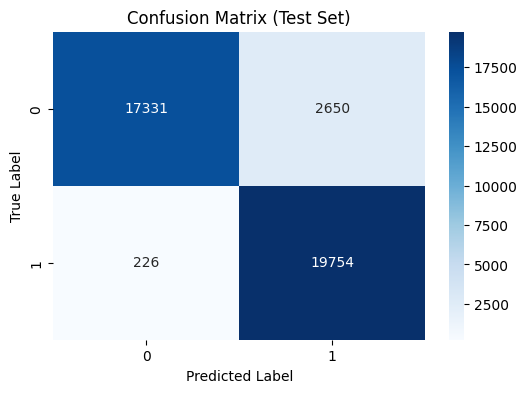

In [ ]:
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

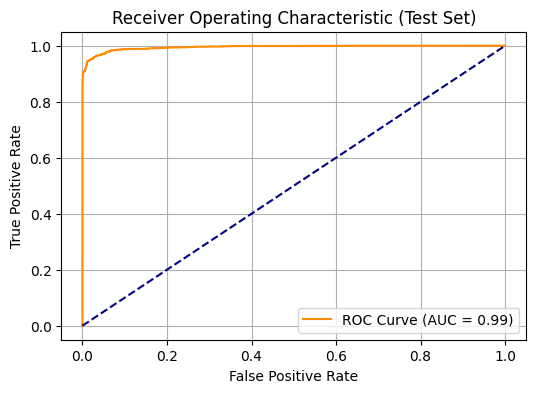

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, test_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {test_auc:.2f})", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (Test Set)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Random Forest Classifier Model

In [ ]:
# Train a Model (Random Forest Classifier)
rf = RandomForestClassifier(n_estimators=100,max_features=0.3,max_depth=5,random_state=42)
rf.fit(X_resampled, y_resampled)

RandomForestClassifier(max_depth=5, max_features=0.3, random_state=42)

# Random Forest Classifier Model Validation

In [ ]:
#Predict test dataset
y_pred = rf.predict(X_test)

In [ ]:
# Print out the classification report
print(classification_report(y_test, y_pred))

# Printing the accuracy result
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


              precision    recall  f1-score   support

           0       0.93      0.96      0.95     19981
           1       0.96      0.93      0.95     19980

    accuracy                           0.95     39961
   macro avg       0.95      0.95      0.95     39961
weighted avg       0.95      0.95      0.95     39961

Model Accuracy: 94.69%


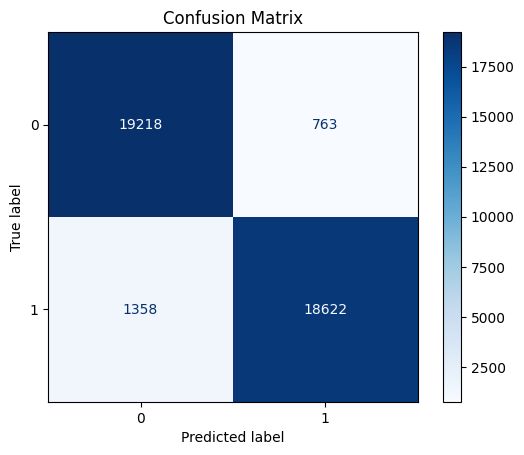

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

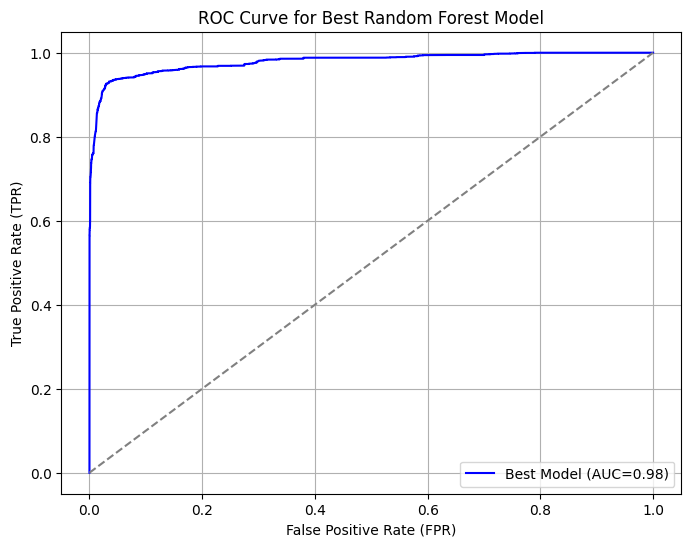

In [ ]:
# ROC Curve
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
# Plot ROC curve for the best model
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Best Model (AUC={roc_auc:.2f})", color='blue')
# Baseline (Random Classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Labels & Legends
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Best Random Forest Model')
plt.legend()
plt.grid()
plt.show()